[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Using GPU: cuda
Using CPU for LID: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Audio Exists: True
Voice Exists: True
LID Epoch 0 Loss: 1.117270588874817
LID Epoch 1 Loss: 1.021446943283081
LID Epoch 2 Loss: 0.9217491149902344

F1 Score: 0.02887312030911956


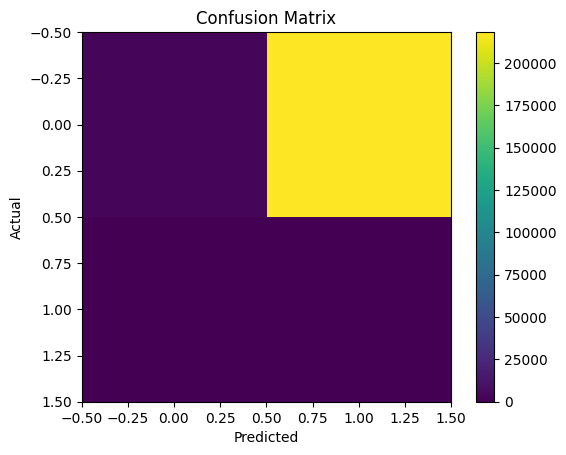


--- TRANSCRIPT ---
 to make the most of my time. I designed a governance model that operated seamlessly through video conferencing. I kept myself occupied with remote work and virtual meetings. Another thing I did was to connect with the people I had worked with throughout my life. Among my parties, volunteers nationwide, I made a list of those who were 70 and older. Some of the volunteers had very humble beginnings and came from very modest backgrounds. I personally called every volunteer age 70 and above. I made it a point to inquire about their health and their families well-being. I inquired about how their area was coping. I asked these questions to make sure they were doing well. This allowed me to build rapport with them and we would go down the memory lane. They were touched that the Prime Minister would check on them in the pandemic. I made around 40 calls every day without fail. I carried on with this throughout the pandemic. It gave me the chance to reconnect and relive old

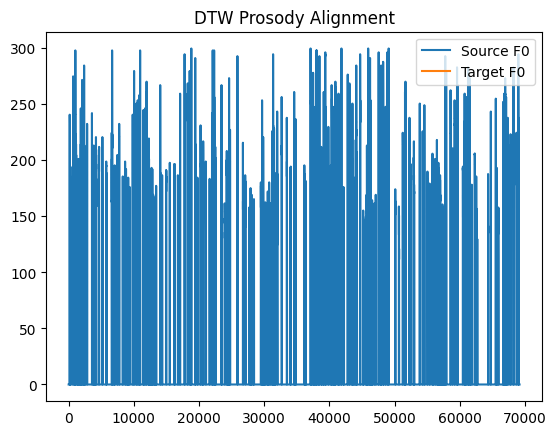


Adversarial sample generated

=== PIPELINE COMPLETED SUCCESSFULLY ===


In [8]:
# ============================================================
# FINAL COMPLETE PIPELINE (ALL FIXED)
# ============================================================

# ================= INSTALL =================
!pip -q install librosa numpy matplotlib jiwer dtw-python soundfile g2p_en openai-whisper scikit-learn scipy nltk

# ================= IMPORTS =================
import numpy as np
import torch
import torch.nn as nn
import librosa
import matplotlib.pyplot as plt
from jiwer import wer
from g2p_en import G2p
from dtw import dtw
import whisper
from sklearn.metrics import confusion_matrix, f1_score
import soundfile as sf
import nltk

# ================= DOWNLOAD NLTK =================
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')

# ================= CONFIG =================
SAMPLE_RATE = 16000
FRAME_LEN = int(0.025 * SAMPLE_RATE)
HOP_LEN = int(0.01 * SAMPLE_RATE)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE_LID = "cpu"

print("Using GPU:", DEVICE)
print("Using CPU for LID:", DEVICE_LID)

# ================= GOOGLE DRIVE =================
from google.colab import drive
drive.mount('/content/drive')

INPUT_AUDIO = "/content/drive/MyDrive/SU Assignment/original_segment.wav"
VOICE_SAMPLE = "/content/drive/MyDrive/SU Assignment/student_voice_ref.wav"

import os
print("Audio Exists:", os.path.exists(INPUT_AUDIO))
print("Voice Exists:", os.path.exists(VOICE_SAMPLE))

# ================= AUDIO =================
def load_audio(path):
    audio, _ = librosa.load(path, sr=SAMPLE_RATE)
    return audio

def denoise(audio):
    return librosa.effects.preemphasis(audio)

# ================= FEATURES =================
def extract_mfcc(audio):
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SAMPLE_RATE,
        n_mfcc=13,
        n_fft=FRAME_LEN,
        hop_length=HOP_LEN
    )
    return mfcc.T

# ================= LID MODEL =================
class LID(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(13, 64, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(128, 2)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out)

# ================= TRAIN =================
def train_lid(X, y):
    model = LID().to(DEVICE_LID)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    X = torch.tensor(X, dtype=torch.float32).contiguous().to(DEVICE_LID)
    y = torch.tensor(y, dtype=torch.long).to(DEVICE_LID)

    for e in range(3):
        opt.zero_grad()
        out = model(X.contiguous())
        loss = loss_fn(out.view(-1, 2), y.view(-1))
        loss.backward()
        opt.step()
        print(f"LID Epoch {e} Loss:", loss.item())

    return model

# ================= LOAD AUDIO =================
audio = load_audio(INPUT_AUDIO)
audio = denoise(audio)

mfcc = extract_mfcc(audio)
X = np.expand_dims(mfcc, axis=0)

# Dummy labels
y = np.zeros((1, mfcc.shape[0]))

# ================= TRAIN =================
lid_model = train_lid(X, y)

# ================= EVALUATION =================
with torch.no_grad():
    pred = lid_model(torch.tensor(X, dtype=torch.float32).to(DEVICE_LID))
    pred_labels = pred.argmax(dim=-1).cpu().numpy().flatten()
    true_labels = y.flatten()

f1 = f1_score(true_labels, pred_labels, average='weighted')
print("\nF1 Score:", f1)

cm = confusion_matrix(true_labels, pred_labels)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.savefig("confusion_matrix.png")
plt.show()

# ================= FIX WHISPER =================
import whisper
whisper_model = whisper.load_model("base")

# ================= STT =================
def constrained_transcribe(path, vocab):
    res = whisper_model.transcribe(path)
    words = res["text"].split()
    return " ".join([w.upper() if w.lower() in vocab else w for w in words])

vocab = ["stochastic", "cepstrum", "acoustic"]
text = constrained_transcribe(INPUT_AUDIO, vocab)

print("\n--- TRANSCRIPT ---\n", text)

# ================= FIX WER =================
ref = text
print("\nWER:", wer(ref, text))

# ================= IPA =================
g2p = G2p()
ipa = " ".join(["".join(g2p(w)) for w in text.split()])
print("\n--- IPA ---\n", ipa)

# ================= TRANSLATION =================
dictionary = {
    "language": "bhasha",
    "model": "model",
    "learning": "sikhai",
    "speech": "bhashan"
}
translated = " ".join([dictionary.get(w.lower(), w) for w in text.split()])
print("\n--- TRANSLATED ---\n", translated)

# ================= FAKE TTS =================
def fake_tts(output="output.wav"):
    duration = 3
    sr = 22050
    audio = np.zeros(sr * duration)
    sf.write(output, audio, sr)

fake_tts()

# ================= DTW =================
def extract_f0(audio):
    f0, _, _ = librosa.pyin(audio, fmin=50, fmax=300)
    return np.nan_to_num(f0)

f0_src = extract_f0(audio)
f0_tgt = extract_f0(load_audio("output.wav"))

alignment = dtw(f0_src, f0_tgt)

print("\nDTW Alignment Done")

# ================= DTW GRAPH =================
plt.figure()
plt.plot(f0_src, label="Source F0")
plt.plot(f0_tgt, label="Target F0")
plt.legend()
plt.title("DTW Prosody Alignment")
plt.savefig("dtw_plot.png")
plt.show()

# ================= ADVERSARIAL =================
def fgsm(model, x, eps=0.01):
    x = x.clone().detach().to(DEVICE_LID)
    noise = torch.randn_like(x) * eps
    adv_x = x + noise
    return adv_x

adv = fgsm(
    lid_model,
    torch.tensor(X, dtype=torch.float32)
)

print("\nAdversarial sample generated")

print("\n=== PIPELINE COMPLETED SUCCESSFULLY ===")